# Práctica 4 — Medidas de Concentración
## Curva de Lorenz y Coeficiente de Gini aplicados a violencia por entidad
**Emiliano** · ENDIREH 2021 · Datos: data/data-processed/endireh_2021_clean.parquet

Nota de sensibilidad: este análisis trata un tema social sensible. Los datos
representan experiencias reales de violencia reportadas por las encuestadas.
Las conclusiones no deben estigmatizar entidades ni minimizar el problema en
entidades con menor concentración relativa.


In [1]:
import sys
from pathlib import Path

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Asegurar que la raíz del proyecto esté en sys.path
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from config.rutas import RUTA_PARQUET_LIMPIO, RUTA_FIGURAS, RUTA_TABLAS
from src.concentracion import (
    lorenz_curve,
    gini,
    gini_sobre_frecuencias,
    concentracion_por_entidad,
)

sns.set_theme(style="whitegrid")
RUTA_FIGURAS.mkdir(parents=True, exist_ok=True)
RUTA_TABLAS.mkdir(parents=True, exist_ok=True)


In [2]:
df = pl.read_parquet(RUTA_PARQUET_LIMPIO)
print("Shape:", df.shape)
print("Columnas:", df.columns)
df.head(3)


Shape: (105296, 26)
Columnas: ['cve_entidad', 'nom_entidad', 'cve_municipio', 'nom_municipio', 'edad_primer_union', 'num_hijos', 'nivel_escolaridad', 'estado_civil_id', 'estado_civil_desc', 'estrato_socioeconomico', 'pareja_trabaja_id', 'pareja_trabaja_desc', 'ingreso_pareja', 'dinero_propio_id', 'dinero_propio_desc', 'apoyo_gobierno_id', 'apoyo_gobierno_desc', 'tiene_ahorros_id', 'tiene_ahorros_desc', 'propietaria_vivienda_id', 'propietaria_vivienda_desc', 'sufrio_violencia_pareja', 'factor_expansion', 'anio_encuesta', 'edad_primer_union_imputada', 'num_hijos_imputado']


cve_entidad,nom_entidad,cve_municipio,nom_municipio,edad_primer_union,num_hijos,nivel_escolaridad,estado_civil_id,estado_civil_desc,estrato_socioeconomico,pareja_trabaja_id,pareja_trabaja_desc,ingreso_pareja,dinero_propio_id,dinero_propio_desc,apoyo_gobierno_id,apoyo_gobierno_desc,tiene_ahorros_id,tiene_ahorros_desc,propietaria_vivienda_id,propietaria_vivienda_desc,sufrio_violencia_pareja,factor_expansion,anio_encuesta,edad_primer_union_imputada,num_hijos_imputado
i64,cat,i64,str,i64,i64,cat,i64,cat,i64,i64,str,f64,i64,str,i64,str,i64,str,i64,str,i8,f64,i64,bool,bool
22,"""queretaro""",11,"""EL MARQUÃS""",21,3,"""c1""",6,"""soltera""",3,2,"""No""",null,2,"""No""",2,"""No""",2,"""No""",1,"""Sí""",0,427.0,2021,true,true
22,"""queretaro""",12,"""PEDRO ESCOBEDO""",21,3,"""a1""",5,"""casada""",2,2,"""No""",null,2,"""No""",2,"""No""",2,"""No""",1,"""Sí""",0,294.0,2021,true,false
13,"""hidalgo""",70,"""TLAHUELILPAN""",21,2,"""b1""",2,"""separada""",2,1,"""Sí""",1000.0,1,"""Sí""",2,"""No""",2,"""No""",2,"""No""",1,263.0,2021,true,false


## 1. Decisiones de análisis
- Nos quedamos sólo con registros que reportaron violencia de pareja
  (sufrio_violencia_pareja == 1).
- Se conserva factor_expansion para ponderar.
- El Gini territorial SÍ se pondera.
- Los índices de heterogeneidad (Shannon, Gini-Simpson) NO se ponderan porque
  operan sobre proporciones de categorías, no sobre poblaciones.


In [3]:
COL_ENTIDAD   = "nom_entidad"
COL_PESO      = "factor_expansion"
COL_VIOLENCIA = "sufrio_violencia_pareja"

df_viol = df.filter(pl.col(COL_VIOLENCIA) == 1)
print("Registros con violencia reportada:", df_viol.height)
print("Total registros:", df.height)
print(f"Prevalencia sin ponderar: {df_viol.height / df.height:.4f}")


Registros con violencia reportada: 19107
Total registros: 105296
Prevalencia sin ponderar: 0.1815


## 2. Concentración territorial de casos por entidad


In [4]:
tabla_ent = concentracion_por_entidad(
    df_viol, col_entidad=COL_ENTIDAD, col_peso=COL_PESO
)
tabla_ent.head(32)


nom_entidad,casos_sin_ponderar,casos_ponderados,proporcion_ponderada
cat,u32,f64,f64
"""mexico""",679,1.333883e6,0.152313
"""ciudad de mexico""",555,698841.0,0.079799
"""veracruz de ignacio de la llav…",662,625007.0,0.071368
"""jalisco""",659,621493.0,0.070967
"""guanajuato""",699,464896.0,0.053085
…,…,…,…
"""zacatecas""",476,88670.0,0.010125
"""nayarit""",669,88147.0,0.010065
"""colima""",631,55656.0,0.006355


In [5]:
gini_pond = gini(tabla_ent["casos_ponderados"].to_numpy())
gini_sin  = gini(tabla_ent["casos_sin_ponderar"].to_numpy())
print(f"Gini territorial ponderado   : {gini_pond:.4f}")
print(f"Gini territorial sin ponderar: {gini_sin:.4f}")


Gini territorial ponderado   : 0.4191
Gini territorial sin ponderar: 0.0956


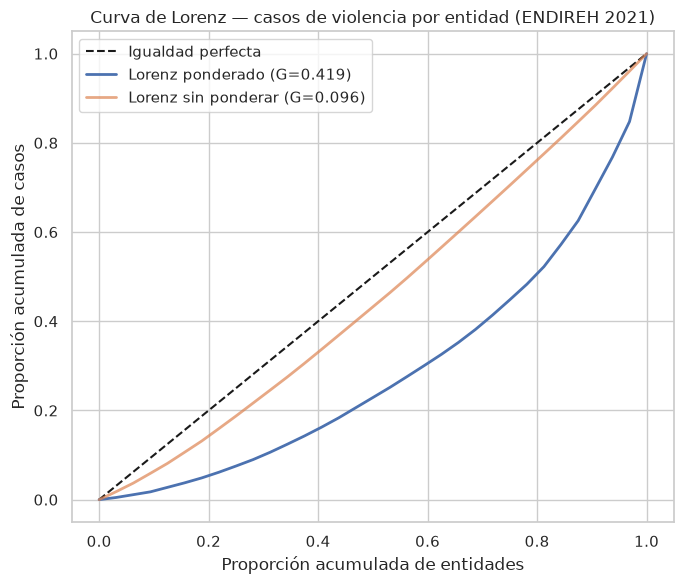

In [6]:
pob_p, cant_p = lorenz_curve(tabla_ent["casos_ponderados"].to_numpy())
pob_s, cant_s = lorenz_curve(tabla_ent["casos_sin_ponderar"].to_numpy())

plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], "k--", label="Igualdad perfecta")
plt.plot(pob_p, cant_p, label=f"Lorenz ponderado (G={gini_pond:.3f})", lw=2)
plt.plot(pob_s, cant_s, label=f"Lorenz sin ponderar (G={gini_sin:.3f})", lw=2, alpha=0.7)
plt.xlabel("Proporción acumulada de entidades")
plt.ylabel("Proporción acumulada de casos")
plt.title("Curva de Lorenz — casos de violencia por entidad (ENDIREH 2021)")
plt.legend()
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "04_lorenz_entidad.png", dpi=150)
plt.show()


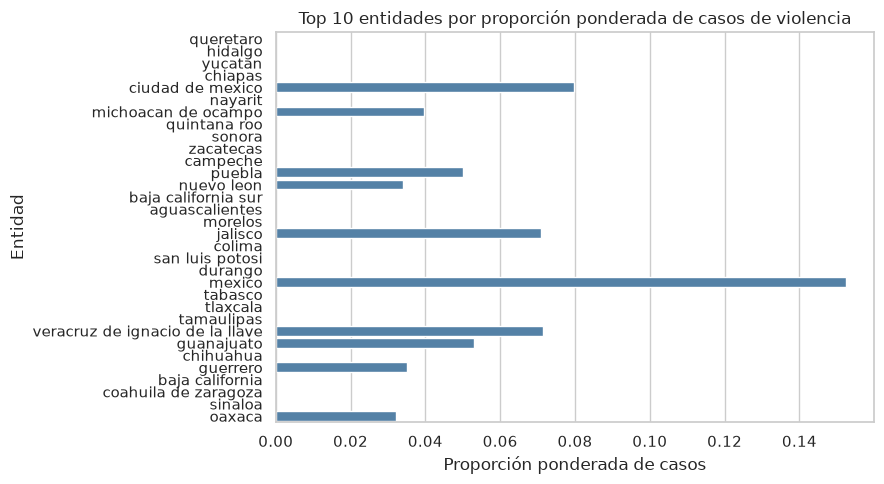

In [7]:
top10 = tabla_ent.sort("proporcion_ponderada", descending=True).head(10)
plt.figure(figsize=(9, 5))
sns.barplot(data=top10.to_pandas(), x="proporcion_ponderada", y=COL_ENTIDAD, color="steelblue")
plt.xlabel("Proporción ponderada de casos")
plt.ylabel("Entidad")
plt.title("Top 10 entidades por proporción ponderada de casos de violencia")
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "04_top10_entidades.png", dpi=150)
plt.show()


### Pregunta 1 — Interpretación de la curva de Lorenz y el Gini

El coeficiente de Gini territorial ponderado por factor_expansion para los
casos de violencia de pareja es G = ___. La curva de Lorenz se separa de la
diagonal de igualdad perfecta en ___, lo que indica que la violencia reportada
está ___ (concentrada / distribuida) entre las entidades federativas.

Advertencia metodológica: un Gini alto NO equivale a "aquí hay más violencia".
Refleja diferencias en el tamaño poblacional (por eso se pondera), en la
disposición a denunciar/reportar y en el operativo de la ENDIREH. La lectura
correcta combina el Gini con la prevalencia ponderada y con el contexto
sociodemográfico de cada entidad.


## 3. Gini aplicado a frecuencias de categorías (para notebook 05)

Se elige nivel_escolaridad (6 categorías) en lugar de sufrio_violencia_pareja
(binaria) porque esta última no permite una comparación informativa entre
concentración y heterogeneidad.


In [8]:
COL_CAT = "nivel_escolaridad"

conteos = (
    df.group_by(COL_CAT)
    .agg(pl.len().alias("n"))
    .sort("n", descending=True)
)
gini_cat = gini_sobre_frecuencias(conteos["n"])
print(f"Gini sobre frecuencias de {COL_CAT}: {gini_cat:.4f}")
conteos


Gini sobre frecuencias de nivel_escolaridad: 0.5198


nivel_escolaridad,n
cat,u32
"""a1""",61669
"""c1""",14425
"""b1""",12546
"""b2""",9497
"""c2""",4765
"""a2""",2394


In [9]:
import json
res = {
    "gini_territorial_ponderado": gini_pond,
    "gini_territorial_sin_ponderar": gini_sin,
    "gini_categorias_nivel_escolaridad": gini_cat,
    "variable_categorica_sintesis": COL_CAT,
    "n_entidades": tabla_ent.height,
    "entidad_top1": tabla_ent[0, COL_ENTIDAD],
    "prop_top1": float(tabla_ent[0, "proporcion_ponderada"]),
    "n_registros_violencia": df_viol.height,
    "n_registros_totales": df.height,
}
with open(RUTA_TABLAS / "resultados_concentracion.json", "w") as f:
    json.dump(res, f, indent=2, ensure_ascii=False)
res


{'gini_territorial_ponderado': 0.41905357283144484,
 'gini_territorial_sin_ponderar': 0.09560141571151934,
 'gini_categorias_nivel_escolaridad': 0.5198108190244644,
 'variable_categorica_sintesis': 'nivel_escolaridad',
 'n_entidades': 32,
 'entidad_top1': 'mexico',
 'prop_top1': 0.15231259112152093,
 'n_registros_violencia': 19107,
 'n_registros_totales': 105296}

### Pregunta 4 — Ética y comunicación

Al publicar un Gini por entidad sobre violencia contra las mujeres:

1. No estigmatizar regiones. Un Gini alto NO significa "entidad violenta";
   refleja reporte, denuncia y estructura poblacional.
2. Contextualizar siempre con prevalencia ponderada, tamaño poblacional y
   nota metodológica de la ENDIREH.
3. Evitar rankings crudos sin contexto: se leen como juicios morales.
4. Reconocer que cada fila es una experiencia real de violencia.
5. Comunicar incertidumbre y no minimizar entidades con Gini bajo: puede
   haber subregistro.
6. Coherencia con Práctica 3: no revictimizar, cuidar el anonimato y aclarar
   que los datos son casos reportados.


## 4. Conclusiones del bloque de concentración
- Gini territorial = ___ → lectura.
- Entidad top-1 concentra ___% de los casos ponderados.
- Implicación para el modelado: si se hace clustering territorial, considerar
  ponderación por factor_expansion y no rankear entidades sin contexto.
